# telos vs STLCG++

Same semantics, timed. telos (eager PyTorch) against [STLCG++](https://arxiv.org/abs/2501.04194)
in both its distributions: `stlcgpp 0.0.2` (PyTorch) and `stljax 1.1.3` (JAX, jit-compiled).
RTX 3080 Laptop (16 GB), torch 2.8.0, jax 0.10.2. All measurements: `bench.py`; cached rows: `results/`.

In [1]:
import torch
from bench import parity, grid, sweep, speedups, plot, cached

gpu = torch.cuda.get_device_properties(0)
gpu.name, round(gpu.total_memory / 1e9, 1)

('NVIDIA GeForce RTX 3080 Laptop GPU', 16.8)

## Parity

Max |telos − STLCG++| over full robustness trajectories, on randomly generated formulas
(20 per depth ∈ {2, 4, 6}, all connectives) and traces (fresh per formula, T = 37).
`exact`: telos `Robustness` vs `approx_method='true'`. `lse`: telos `LSE(p=β)` vs `'logsumexp'`, `temperature=β`.

In [2]:
for backend in ('torch', 'jax'):
    rows = parity(backend)
    worst = max(rows, key=lambda r: r['lse'])
    print(f"{backend:<6} {len(rows)} formulas   worst exact {max(r['exact'] for r in rows):.1e}"
          f"   worst lse {worst['lse']:.1e}  ({worst['formula']})")

torch  60 formulas   worst exact 0.0e+00   worst lse 9.5e-07  (¬ ((⊤) 𝒰 (¬ (¬ ((⊤) 𝒰 (¬ (¬ ((⊤) 𝒰 (¬ (p ∧ p))))))))))


jax    60 formulas   worst exact 0.0e+00   worst lse 9.5e-07  ((¬ ((⊤) 𝒰 (¬ ((⊤) 𝒰 ((¬ ((⊤) 𝒰 (¬ (q → q)))) ∧ q))))) ∨ (((q ∧ p) → p) ∨ ((q ∨ p) ∨ ((⊤) 𝒰 q))))


## Timing grid

telos vs `stlcgpp`, four formulas, T ∈ {64 … 4096} × B ∈ {1, 16, 64}, exact and lse, forward and forward+backward.
Geometric mean (min, max) of the per-cell speedup; `oom` lists (T, B) cells where `stlcgpp` runs out of memory on `U`.

In [3]:
s = speedups(cached('grid', lambda: grid()))
for k, v in s.items():
    print(k, tuple(round(x, 1) for x in v) if isinstance(v, tuple) else v)

('◇/□', 'fwd') (8.7, 2.5, 104.5)
('◇/□', 'fwd+bwd') (3.6, 1.3, 33.1)
('U', 'fwd') (85.6, 44.1, 268.1)
('U', 'fwd+bwd') (47.0, 20.1, 140.4)
cells 112
oom [(256, 64), (1024, 1), (1024, 16), (4096, 1)]


## Scaling

Dense T sweep, batch 1, exact semantics, forward+backward. Lines end where an implementation
stops being measurable (OOM, or steady-state runtime past 30 s). `masked` is STLCG++'s default;
`recurrent` its sequential fallback. jax cells are jit-compiled, steady-state timed.

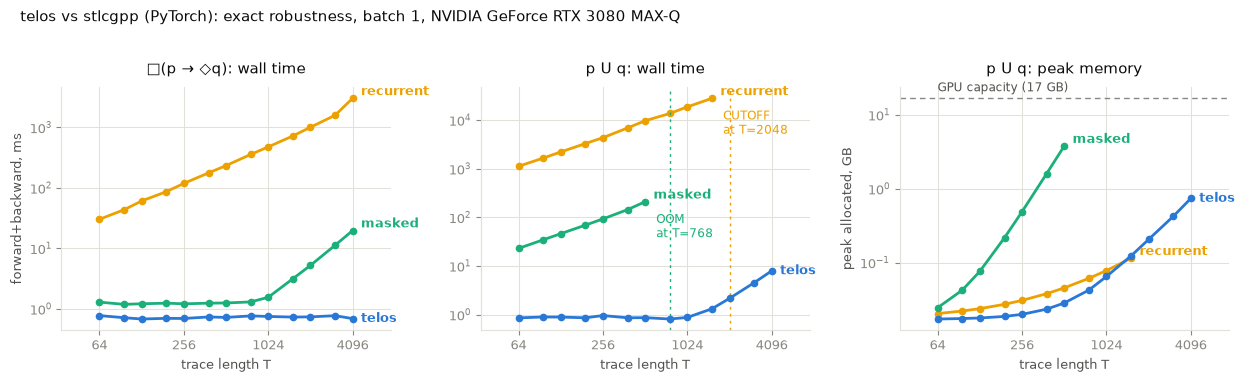

In [4]:
fig = plot(cached('sweep-torch', lambda: sweep('torch')),
           'telos vs stlcgpp (PyTorch): exact robustness, batch 1, NVIDIA GeForce RTX 3080 MAX-Q', total_gb=gpu.total_memory / 1e9)
fig.savefig('scaling.png', dpi=200, bbox_inches='tight')

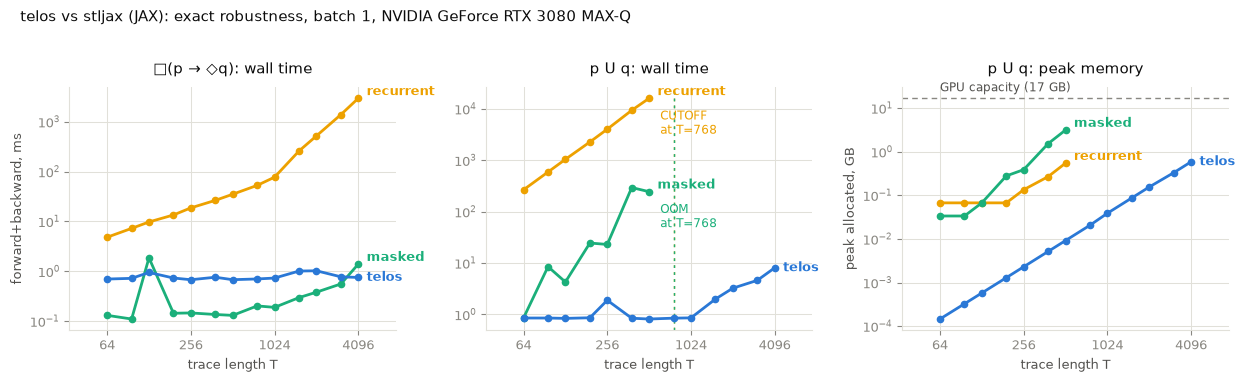

In [5]:
plot(cached('sweep-jax', lambda: sweep('jax')),
     'telos vs stljax (JAX): exact robustness, batch 1, NVIDIA GeForce RTX 3080 MAX-Q', total_gb=gpu.total_memory / 1e9);

telos derives temporal operators from per-algebra sequence reductions with closed forms:
`◇`/`□` are O(T) scans, unbounded `U` an O(T²) span. The masking construction is O(T²) and O(T³)
respectively, in either framework; XLA compiles it well at small T but does not change its asymptotics.